<a href="https://colab.research.google.com/github/EvADarya/Data_processing-DLS-/blob/main/lab2_clust.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
df = pd.read_csv('/content/cat_breeds_clean.csv',sep = ';')

In [ ]:
df

,Breed,Age_in_years,Age_in_months,Gender,Neutered_or_spayed,Body_length,Weight,Fur_colour_dominant,Fur_pattern,Eye_colour,Allowed_outdoor,Preferred_food,Owner_play_time_minutes,Sleep_time_hours,Country,Latitude,Longitude
0,Angora,0.25,3,female,False,19,2.0,white,solid,blue,False,wet,46,16,France,43.296482,5.369780
1,Angora,0.33,4,male,False,19,2.5,white,solid,blue,False,wet,48,16,France,43.611660,3.877710
2,Angora,0.50,6,male,False,20,2.8,black,solid,green,False,wet,41,11,France,44.837789,-0.579180
3,Angora,0.50,6,female,False,21,3.0,white,solid,blue,False,wet,24,8,France,43.611660,3.877710
4,Angora,0.50,6,male,False,21,3.0,red/cream,tabby,green,False,wet,51,10,France,48.864716,2.349014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1066,Maine coon,0.17,2,female,False,15,1.2,white,solid,blue,False,wet,35,20,UK,51.507351,-0.127758
1067,Maine coon,0.17,2,female,False,17,1.0,black,bicolor,blue,False,wet,36,19,UK,51.507351,-0.127758
1068,Maine coon,0.17,2,male,False,14,0.7,red/cream,tabby,blue,False,wet,20,20,UK,51.507351,-0.127758
1069,Maine coon,0.17,2,male,False,16,1.1,red/cream,tabby,green,False,wet,34,19,UK,52.486244,-1.890401


In [ ]:
plt.figure(figsize=(14, 6))
breed_color_counts = df.groupby(['Breed', 'Eye_colour']).size().reset_index(name='count')
sns.barplot(data=breed_color_counts,x='Breed', y='count')
plt.title('Breed vs Fur Colour Dominant')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'Breed'

<Figure size 1400x600 with 0 Axes>

Text(0.5, 1.0, 'Distribution of breeds')

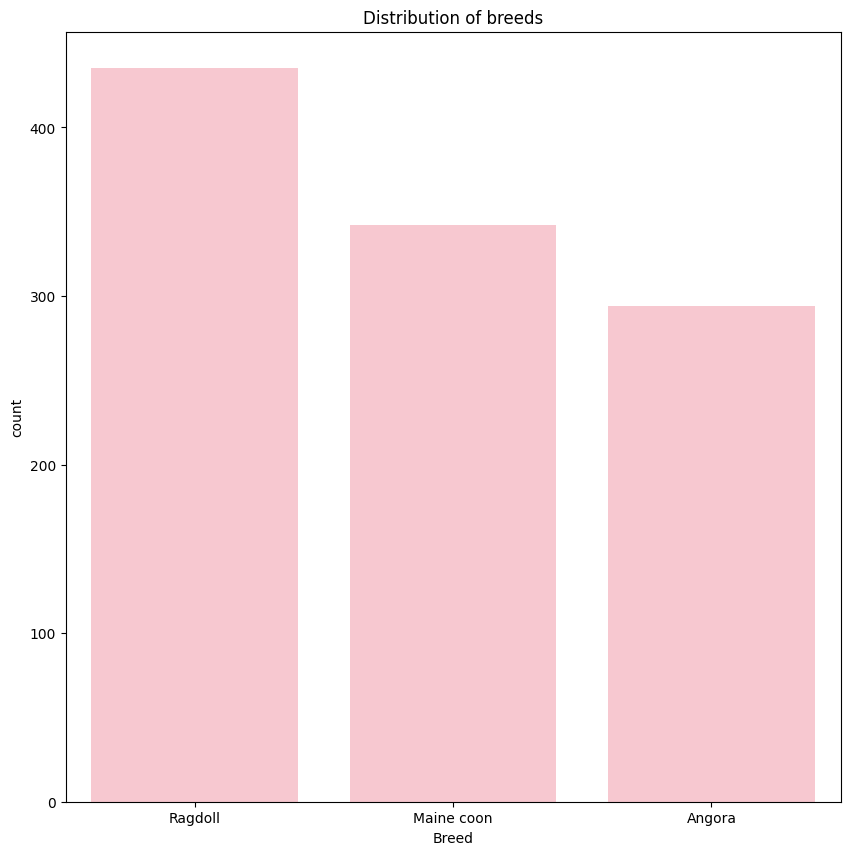

In [ ]:
plt.figure(figsize = (10,10))
sns.countplot(data = df, x = 'Breed', order = df['Breed'].value_counts().index, color = 'pink')
plt.title("Distribution of breeds")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Breed                    1071 non-null   object 
 1   Age_in_years             1071 non-null   float64
 2   Age_in_months            1071 non-null   int64  
 3   Gender                   1071 non-null   object 
 4   Neutered_or_spayed       1071 non-null   bool   
 5   Body_length              1071 non-null   int64  
 6   Weight                   1071 non-null   float64
 7   Fur_colour_dominant      1071 non-null   object 
 8   Fur_pattern              1071 non-null   object 
 9   Eye_colour               1071 non-null   object 
 10  Allowed_outdoor          1071 non-null   bool   
 11  Preferred_food           1071 non-null   object 
 12  Owner_play_time_minutes  1071 non-null   int64  
 13  Sleep_time_hours         1071 non-null   int64  
 14  Country                 

In [ ]:
target_col = df['Breed']
df.drop('Breed', axis = 1, inplace = True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])
df['Fur_colour_dominant'] = encoder.fit_transform(df['Fur_colour_dominant'])
df['Fur_pattern'] = encoder.fit_transform(df['Fur_pattern'])
df['Preferred_food'] = encoder.fit_transform(df['Preferred_food'])
df['Country'] = encoder.fit_transform(df['Country'])
df['Eye_colour'] = encoder.fit_transform(df['Eye_colour'])

In [ ]:
df['Neutered_or_spayed'] = df['Neutered_or_spayed'].astype(int)
df['Allowed_outdoor'] = df['Allowed_outdoor'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age_in_years             1071 non-null   float64
 1   Age_in_months            1071 non-null   int64  
 2   Gender                   1071 non-null   int64  
 3   Neutered_or_spayed       1071 non-null   int64  
 4   Body_length              1071 non-null   int64  
 5   Weight                   1071 non-null   float64
 6   Fur_colour_dominant      1071 non-null   int64  
 7   Fur_pattern              1071 non-null   int64  
 8   Eye_colour               1071 non-null   int64  
 9   Allowed_outdoor          1071 non-null   int64  
 10  Preferred_food           1071 non-null   int64  
 11  Owner_play_time_minutes  1071 non-null   int64  
 12  Sleep_time_hours         1071 non-null   int64  
 13  Country                  1071 non-null   int64  
 14  Latitude                

<Axes: >

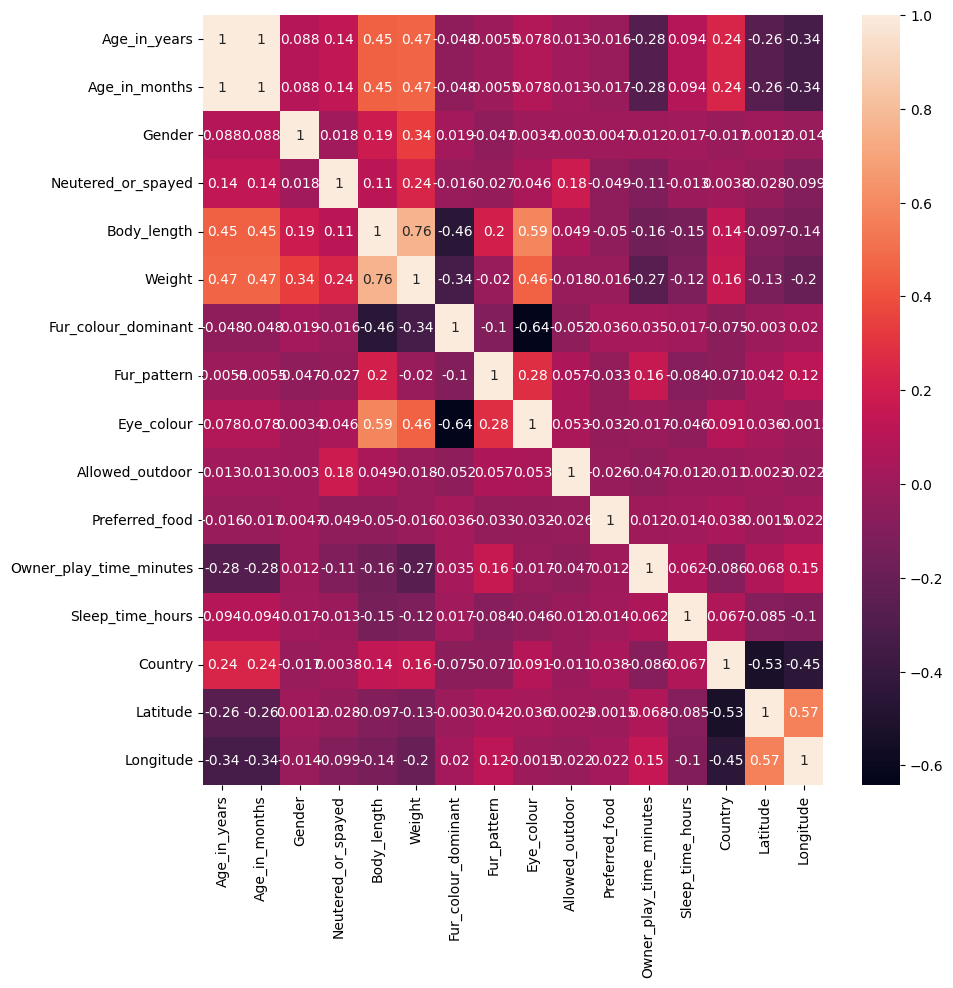

In [ ]:
plt.figure(figsize = (10,10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot = True)

In [ ]:
df.drop('Age_in_months', axis = 1, inplace = True)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_trans = scaler.fit_transform(df)

In [ ]:
from sklearn.cluster import KMeans, DBSCAN

In [ ]:
model_kmeans = KMeans(n_clusters = 3, random_state = 42, algorithm = 'lloyd')
df['Cluster_k_means'] = model_kmeans.fit_predict(df_trans)

In [ ]:
target_col = encoder.fit_transform(target_col)

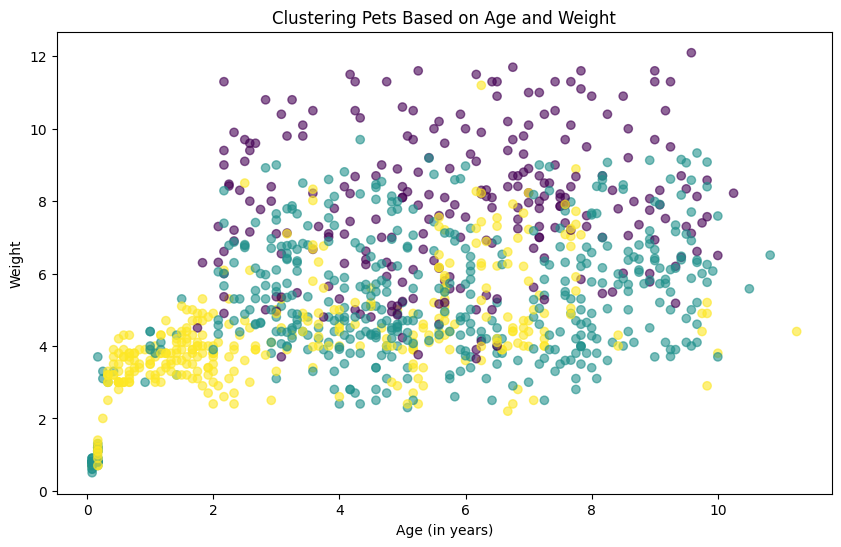

Cluster_k_means
1    481
2    340
0    250
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age_in_years'], df['Weight'], c=df['Cluster_k_means'], cmap='viridis', alpha=0.6)
plt.title('Clustering Pets Based on Age and Weight')
plt.xlabel('Age (in years)')
plt.ylabel('Weight')
plt.show()

print(df['Cluster_k_means'].value_counts())

In [ ]:
target_col
# 0 - Angore , 1 - Mein Coune, 2 - Ragdool

True

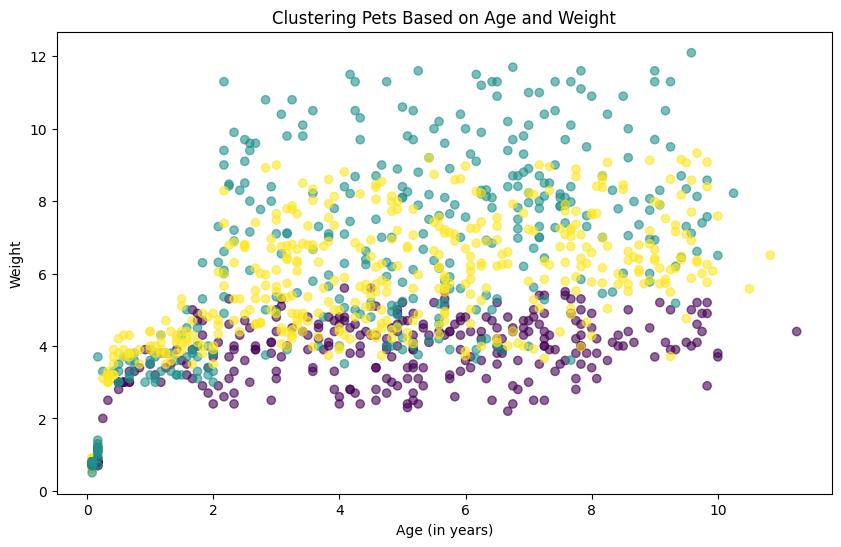

Cluster_k_means
1    481
2    340
0    250
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age_in_years'], df['Weight'], c=target_col, cmap='viridis', alpha=0.6)
plt.title('Clustering Pets Based on Age and Weight')
plt.xlabel('Age (in years)')
plt.ylabel('Weight')
plt.show()

print(df['Cluster_k_means'].value_counts())

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
silhouette_score_K_mean = silhouette_score(df, model_kmeans.predict(df_trans))
calinski_harabasz_score_K_mean = calinski_harabasz_score(df, model_kmeans.predict(df_trans))

In [ ]:
print(f"SILHOUETTE SCORE: {silhouette_score_K_mean:.3f}")
print(f"CALINSKI-HARABASZ INDEX: {calinski_harabasz_score_K_mean:.1f}")

SILHOUETTE SCORE: 0.267
CALINSKI-HARABASZ INDEX: 507.5


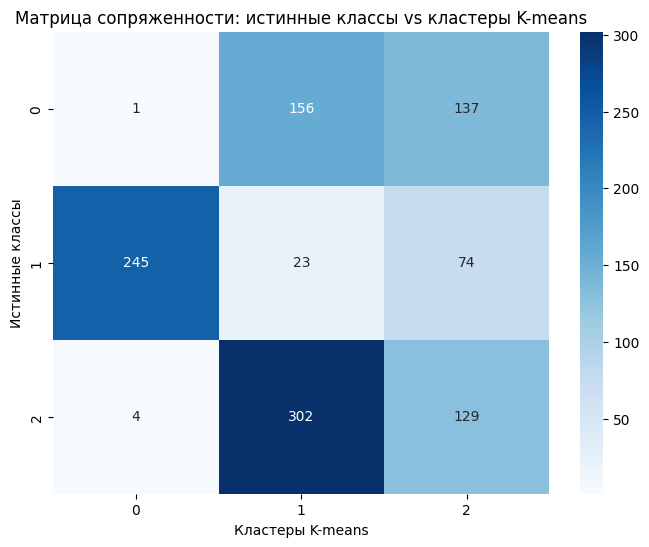

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(target_col, df['Cluster_k_means'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица сопряженности: истинные классы vs кластеры K-means')
plt.ylabel('Истинные классы')
plt.xlabel('Кластеры K-means')
plt.show()

In [ ]:
dbscan = DBSCAN(eps=2.7, min_samples=12)
dbscan_labels = dbscan.fit_predict(df_trans)
df['dbscan_cluster'] = dbscan_labels

In [ ]:
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

In [ ]:
n_noise

272

In [ ]:
n_clusters_dbscan

3

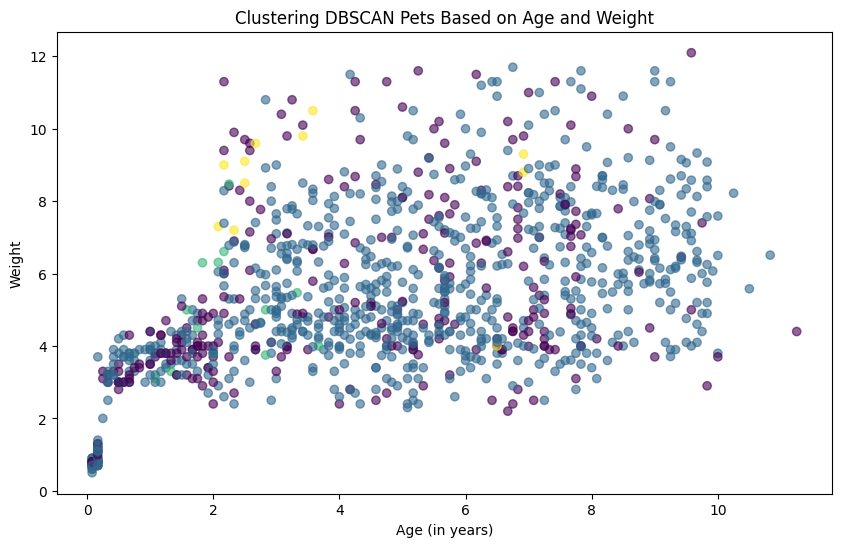

dbscan_cluster
 0    774
-1    272
 1     14
 2     11
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age_in_years'], df['Weight'], c=df['dbscan_cluster'], cmap='viridis', alpha=0.6)
plt.title('Clustering DBSCAN Pets Based on Age and Weight')
plt.xlabel('Age (in years)')
plt.ylabel('Weight')
plt.show()

print(df['dbscan_cluster'].value_counts())

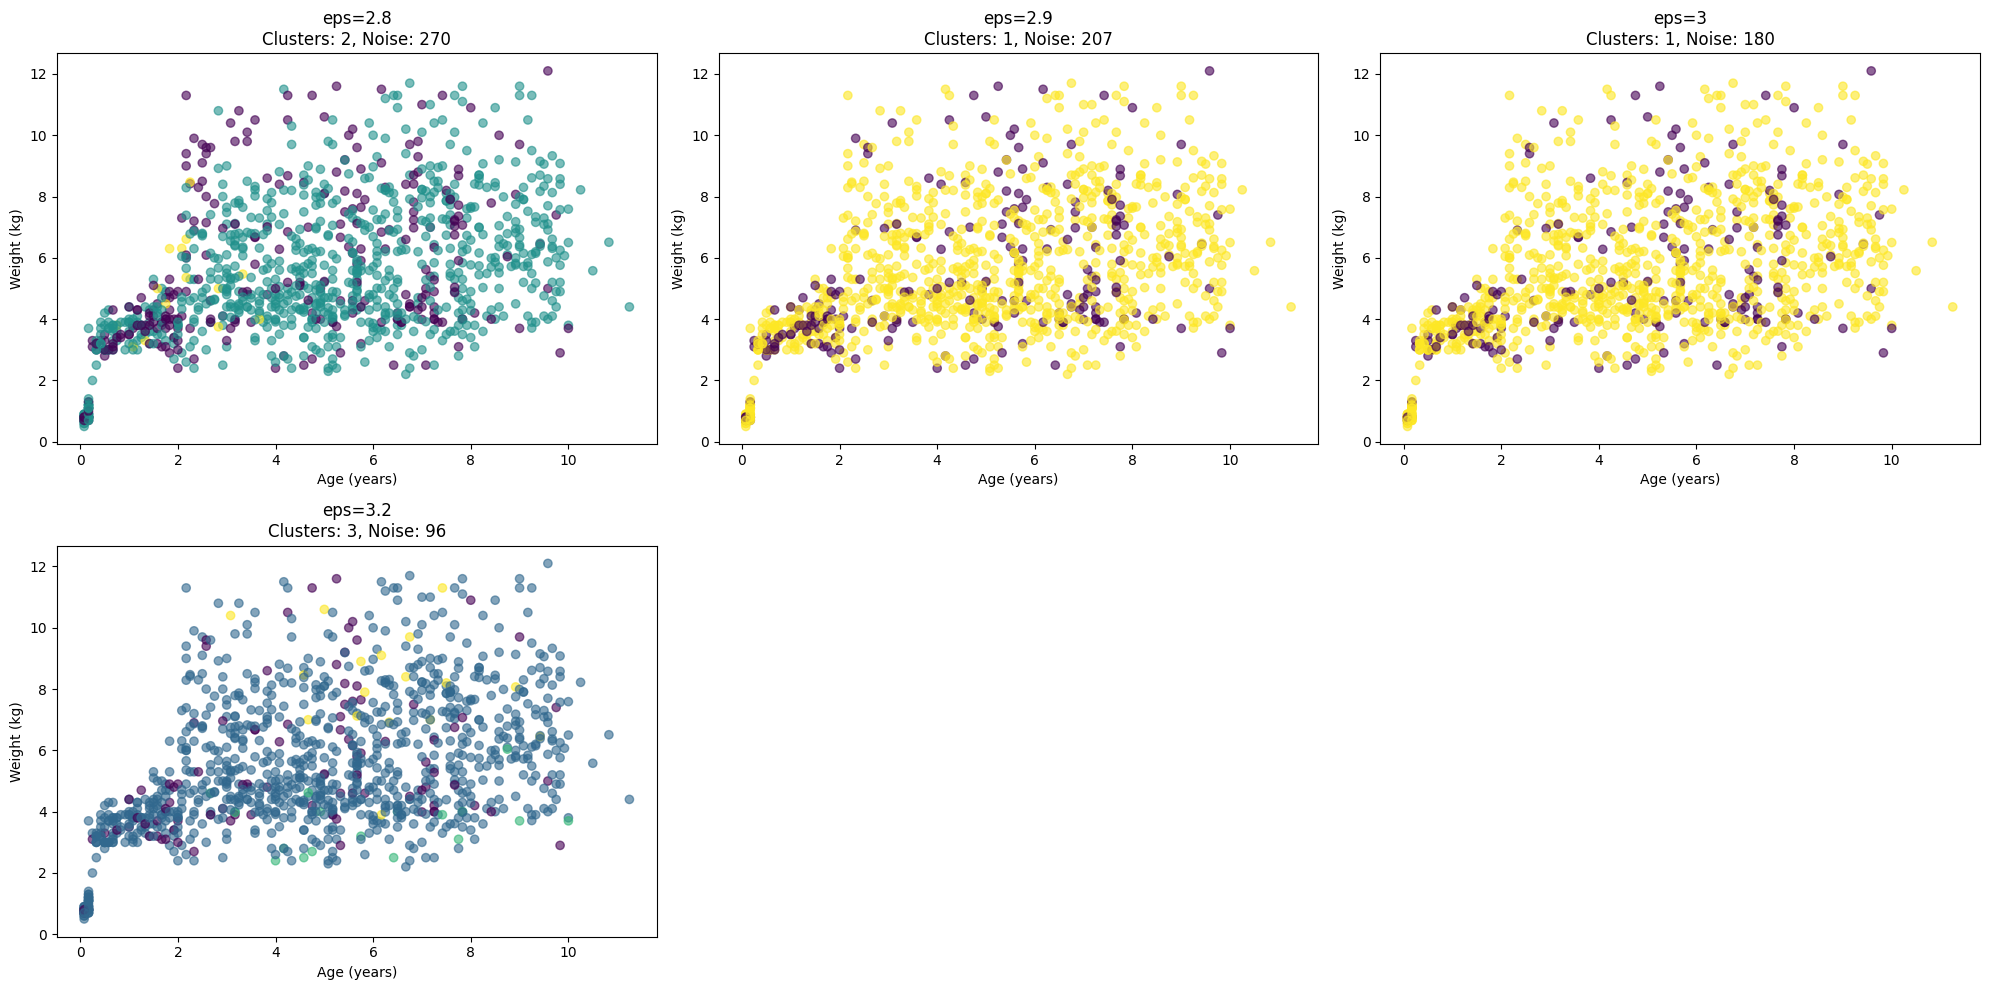


eps=2.8:
-1    270
 0    787
 1     14
Name: count, dtype: int64

eps=2.9:
-1    207
 0    864
Name: count, dtype: int64

eps=3:
-1    180
 0    891
Name: count, dtype: int64

eps=3.2:
-1     96
 0    941
 1     17
 2     17
Name: count, dtype: int64


In [ ]:
eps_values = [2.8,2.9,3,3.2]
min_samples = 15  # фиксированное значение

plt.figure(figsize=(20, 10))

for i, eps in enumerate(eps_values, 1):
    plt.subplot(2, 3, i)

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(df_trans)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    plt.scatter(df['Age_in_years'], df['Weight'], c=labels, cmap='viridis', alpha=0.6)
    plt.title(f'eps={eps}\nClusters: {n_clusters}, Noise: {n_noise}')
    plt.xlabel('Age (years)')
    plt.ylabel('Weight (kg)')

plt.tight_layout()
plt.show()

# Статистика
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(df_trans)

    print(f"\neps={eps}:")
    print(pd.Series(labels).value_counts().sort_index())

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

non_noise_mask = labels != -1
df_non_noise = df[non_noise_mask]
labels_non_noise = labels[non_noise_mask]

silhouette_avg = silhouette_score(df_non_noise, labels_non_noise)
h_score = calinski_harabasz_score(df_non_noise, labels_non_noise)

In [ ]:
print(f"SILHOUETTE SCORE: {silhouette_avg:.3f}")
print(f"CALINSKI-HARABASZ INDEX: {h_score:.1f}")

SILHOUETTE SCORE: -0.241


In [ ]:
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering

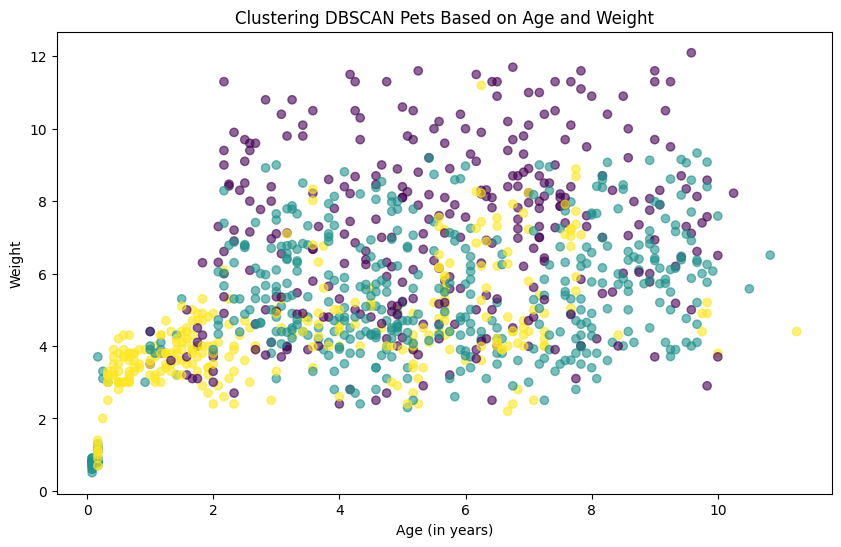

cluster_aglom
1    452
0    316
2    303
Name: count, dtype: int64


In [ ]:
model = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

labels = model.fit_predict(df_trans)
df['cluster_aglom'] = labels

plt.figure(figsize=(10, 6))
plt.scatter(df['Age_in_years'], df['Weight'], c=df['cluster_aglom'], cmap='viridis', alpha=0.6)
plt.title('Clustering DBSCAN Pets Based on Age and Weight')
plt.xlabel('Age (in years)')
plt.ylabel('Weight')
plt.show()

print(df['cluster_aglom'].value_counts())

In [ ]:
hierarchical_silhouette_aglom = silhouette_score(df_trans, df['cluster_aglom'])
calinski_harabasz_score_aglom = calinski_harabasz_score(df_trans, df['cluster_aglom'])
print(f"SILHOUETTE SCORE: {hierarchical_silhouette_aglom:.3f}")
print(f"CALINSKI-HARABASZ INDEX: {calinski_harabasz_score_aglom:.1f}")

SILHOUETTE SCORE: 0.139
CALINSKI-HARABASZ INDEX: 153.6


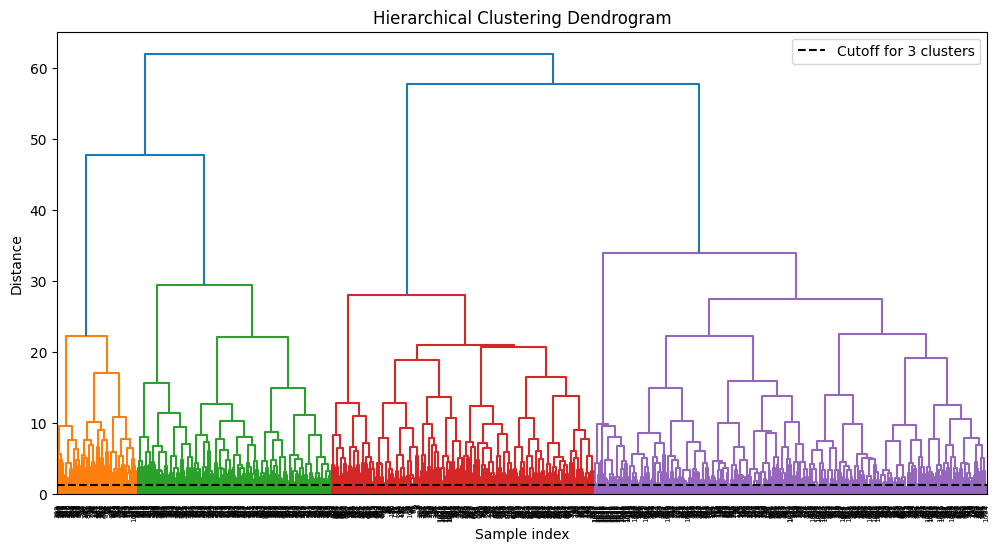

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Вычисляем связи для дендрограммы
Z = linkage(df_trans, method='ward')

# Строим дендрограмму
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.axhline(y=1.2, c='k', linestyle='--', label='Cutoff for 3 clusters')
plt.legend()
plt.show()

